# Test Notebook — Verify CalAdapt / Climakitae Setup

A lightweight smoke test that fetches a small slice of data to confirm:
1. climakitae imports and connects to Cal-Adapt
2. `get_data()` returns data on Apple Silicon
3. Geospatial stack (geopandas, rioxarray) works with our shapefiles
4. Masking + spatial averaging pipeline runs end-to-end
5. CSV export works

**Bounded to keep it fast:**
- 1 region (Joshua Tree only)
- 1 scenario (Historical Climate)
- 1 variable (Max Temperature)
- 5-year time window (2010–2014)

Should finish in under a minute.

## 1. Import Test

In [1]:
import climakitae as ck
from climakitae.core.data_interface import get_data
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
import cartopy
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

print(f"climakitae version: {ck.__version__}")
print(f"xarray version:     {xr.__version__}")
print(f"geopandas version:  {gpd.__version__}")
print(f"numpy version:      {np.__version__}")
print(f"cartopy version:    {cartopy.__version__}")
print("\n All imports OK!")

/Users/andrewschoenen/miniconda3/envs/py-env/lib/python3.12/site-packages/intake_esm/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


climakitae version: 1.3.0
xarray version:     2025.11.0
geopandas version:  1.1.2
numpy version:      2.3.5
cartopy version:    0.25.0

 All imports OK!


## 2. Load Shapefile

Joshua Tree bounds: [-116.45804115   33.67018976 -115.2622015    34.12934662]
  Lon: -116.458 to -115.262
  Lat: 33.670 to 34.129


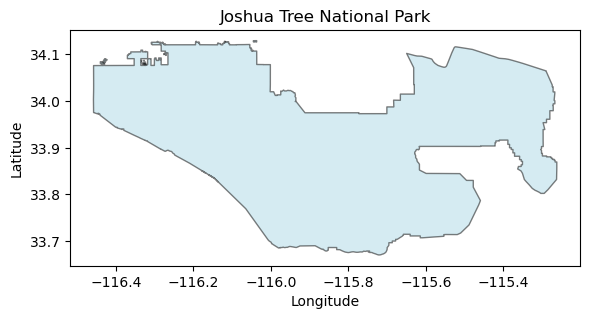


 Shapefile loaded and plotted!


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
PARK_OUTLINES_DIR = os.path.join(PROJECT_ROOT, "parkOutlines")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "data", "csv")
os.makedirs(OUTPUT_DIR, exist_ok=True)

jt_path = os.path.join(PARK_OUTLINES_DIR, "JoshuaTree", "Joshua_Tree_National_Park.shp")
boundary = gpd.read_file(jt_path).to_crs("EPSG:4326")

bounds = boundary.total_bounds  # [minx, miny, maxx, maxy]
print(f"Joshua Tree bounds: {bounds}")
print(f"  Lon: {bounds[0]:.3f} to {bounds[2]:.3f}")
print(f"  Lat: {bounds[1]:.3f} to {bounds[3]:.3f}")

# Quick plot of the boundary
fig, ax = plt.subplots(figsize=(6, 4))
boundary.plot(ax=ax, edgecolor="black", facecolor="lightblue", alpha=0.5)
ax.set_title("Joshua Tree National Park")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()
print("\n Shapefile loaded and plotted!")

## 3. Fetch Data from Cal-Adapt

Small request: 1 variable, 1 scenario, 5 years, bounded to Joshua Tree.

In [3]:
print("Fetching data from Cal-Adapt...")
print("  Variable:    Maximum air temperature at 2m")
print("  Resolution:  3 km (Statistical)")
print("  Scenario:    Historical Climate")
print("  Time:        2010-2014 (5 years only)")
print("  Bounds:      Joshua Tree NP")
print()

data = get_data(
    variable="Maximum air temperature at 2m",
    resolution="3 km",
    downscaling_method="Statistical",
    timescale="monthly",
    scenario=["Historical Climate"],
    time_slice=(2010, 2014),
    latitude=(bounds[1], bounds[3]),
    longitude=(bounds[0], bounds[2])
)

print(f"\n Received data!")
print(f"  Type:       {type(data).__name__}")
print(f"  Shape:      {data.shape}")
print(f"  Dims:       {data.dims}")
print(f"  Coords:     {list(data.coords)}")
print(f"  Time range: {str(data.time.values[0])[:10]} to {str(data.time.values[-1])[:10]}")
print(f"  Units:      {data.attrs.get('units', 'N/A')}")
data

Fetching data from Cal-Adapt...
  Variable:    Maximum air temperature at 2m
  Resolution:  3 km (Statistical)
  Scenario:    Historical Climate
  Time:        2010-2014 (5 years only)
  Bounds:      Joshua Tree NP


 Received data!
  Type:       DataArray
  Shape:      (1, 70, 60, 15, 39)
  Dims:       ('scenario', 'simulation', 'time', 'lat', 'lon')
  Coords:     ['lat', 'lon', 'time', 'simulation', 'scenario', 'spatial_ref']
  Time range: 2010-01-01 to 2014-12-01
  Units:      K


<xarray.DataArray np.str_('Maximum air temperature at 2m') (scenario: 1,
                                                            simulation: 70,
                                                            time: 60, lat: 15,
                                                            lon: 39)> Size: 10MB
dask.array<getitem, shape=(1, 70, 60, 15, 39), dtype=float32, chunksize=(1, 1, 60, 15, 39), chunktype=numpy.ndarray>
Coordinates:
  * scenario     (scenario) <U18 72B 'Historical Climate'
  * simulation   (simulation) <U30 8kB 'LOCA2_TaiESM1_r1i1p1f1' ... 'LOCA2_MP...
  * time         (time) datetime64[ns] 480B 2010-01-01 2010-02-01 ... 2014-12-01
  * lat          (lat) float32 60B 33.67 33.7 33.73 33.77 ... 34.05 34.08 34.11
  * lon          (lon) float32 156B -116.5 -116.4 -116.4 ... -115.3 -115.3
    spatial_ref  int64 8B 0
Attributes:
    variable_id:           tasmax
    extended_description:  The maximum daily air temperature at 2m above the ...
    units:                 K
    data_type:             Gridded
    resolution:            3 km
    frequency:             monthly
    location_subset:       ['coordinate selection']
    approach:              Time
    downscaling_method:    Statistical
    institution:           UCSD

## 4. Fetch Strategy Benchmarks

**Discovery:** `get_data()` is **NOT thread-safe** — it internally creates a `DataParameters` 
object that fetches boundary data from S3, and concurrent calls cause race conditions 
(`AttributeError: 'NoneType' object has no attribute 'query'`).

**Revised approach:** `get_data()` returns a lazy dask DataArray in ~29s (metadata + catalog lookup).
The actual bottleneck is `.load()` which pulls ~10MB from Cal-Adapt's Zarr store in ~90s per call.
So we **serialize `get_data()`** but **parallelize `.load()`** via threads.

### Four strategies:
| # | Strategy | `get_data()` | `.load()` | Averaging |
|---|----------|-------------|-----------|-----------|
| A | Fully sequential (baseline) | serial | serial | local clip + cos-weighted |
| B | Serial fetch, parallel load | serial | 3 threads | local clip + cos-weighted |
| C | County subset, parallel load | serial (`area_subset`) | 3 threads | local clip + cos-weighted |
| D | Server-side `area_average` | serial (`area_average="Yes"`) | 3 threads | **server simple avg** |

**A, B, C produce identical results** (verified with `np.allclose`).  
**D produces different values** — county-wide simple average, not park-clipped or cos-weighted.

In [4]:
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# ── Shared config ───────────────────────────────────────────

VARIABLES = {
    "T_Max":  "Maximum air temperature at 2m",
    "T_Min":  "Minimum air temperature at 2m",
    "Precip": "Precipitation (total)",
}
SCENARIO   = "Historical Climate"
RES        = "3 km"
DOWNSCALE  = "Statistical"
TIME_SLICE = (2010, 2014)

# ── Helpers ─────────────────────────────────────────────────

def preprocess(da, var_key):
    """Unit conversion + CRS setup."""
    if da.attrs.get("units") == "K":
        da = da - 273.15
        da.attrs["units"] = "°C"
    elif var_key == "Precip":
        days = da.time.dt.days_in_month
        da = da * 86400 * days
        da.attrs["units"] = "mm/month"
    if da.rio.crs is None:
        da = da.rio.write_crs("EPSG:4326")
    yd = next(d for d in ("latitude", "lat", "y") if d in da.dims)
    xd = next(d for d in ("longitude", "lon", "x") if d in da.dims)
    da = da.rio.set_spatial_dims(x_dim=xd, y_dim=yd)
    return da, yd, xd

def load_and_average(da, var_key, boundary):
    """load() → clip → cos-weighted spatial average. Thread-safe (no get_data)."""
    da, yd, xd = preprocess(da, var_key)
    loaded = da.load()                  # ← this is the ~90s network bottleneck
    masked = loaded.rio.clip(boundary.geometry.values, all_touched=True, drop=False)
    weights = np.cos(np.deg2rad(masked[yd]))
    weights.name = "weights"
    avg = masked.weighted(weights).mean(dim=[xd, yd], skipna=True)
    return var_key, avg

def preprocess_no_spatial(da, var_key):
    """Unit conversion only (for area_average data with no lat/lon dims)."""
    if da.attrs.get("units") == "K":
        da = da - 273.15
        da.attrs["units"] = "°C"
    elif var_key == "Precip":
        days = da.time.dt.days_in_month
        da = da * 86400 * days
        da.attrs["units"] = "mm/month"
    return da

# ================================================================
# Phase 1: Serial get_data() calls for each strategy
#   get_data() is NOT thread-safe (DataParameters.__init__ fetches
#   boundary data from S3, and concurrent calls race on _us_states)
# ================================================================

print("Phase 1: Fetching lazy DataArrays (serial — get_data not thread-safe)")
print("-" * 65)

# Park-tight fetches (for strategies A & B)
lazy_park = {}
for vk, vname in VARIABLES.items():
    t0 = time.perf_counter()
    lazy_park[vk] = get_data(
        variable=vname, resolution=RES,
        downscaling_method=DOWNSCALE, timescale="monthly",
        scenario=[SCENARIO], time_slice=TIME_SLICE,
        latitude=(bounds[1], bounds[3]),
        longitude=(bounds[0], bounds[2]),
    )
    print(f"  park-tight  {vk:6s}: {time.perf_counter()-t0:5.1f}s  shape={lazy_park[vk].shape}")

# County-grid fetches (for strategy C)
lazy_county = {}
for vk, vname in VARIABLES.items():
    t0 = time.perf_counter()
    lazy_county[vk] = get_data(
        variable=vname, resolution=RES,
        downscaling_method=DOWNSCALE, timescale="monthly",
        scenario=[SCENARIO], time_slice=TIME_SLICE,
        area_subset="CA counties",
        cached_area=["San Bernardino County"],
    )
    print(f"  county-grid {vk:6s}: {time.perf_counter()-t0:5.1f}s  shape={lazy_county[vk].shape}")

# Server-side area_average fetches (for strategy D)
lazy_avg = {}
for vk, vname in VARIABLES.items():
    t0 = time.perf_counter()
    lazy_avg[vk] = get_data(
        variable=vname, resolution=RES,
        downscaling_method=DOWNSCALE, timescale="monthly",
        scenario=[SCENARIO], time_slice=TIME_SLICE,
        area_subset="CA counties",
        cached_area=["San Bernardino County"],
        area_average="Yes",
    )
    print(f"  server-avg  {vk:6s}: {time.perf_counter()-t0:5.1f}s  shape={lazy_avg[vk].shape}")

print(f"\nAll lazy arrays ready. Now benchmarking .load() strategies...\n")

# ================================================================
# STRATEGY A: Fully sequential — load one at a time
# ================================================================

print("=" * 65)
print("STRATEGY A: Fully sequential (baseline)")
print("=" * 65)

results_a = {}
t0 = time.perf_counter()
for vk in VARIABLES:
    t_load = time.perf_counter()
    _, avg = load_and_average(lazy_park[vk], vk, boundary)
    results_a[vk] = avg
    print(f"  {vk:6s} load+avg: {time.perf_counter()-t_load:5.1f}s")
t_a = time.perf_counter() - t0
print(f"  TOTAL: {t_a:.1f}s\n")

# ================================================================
# STRATEGY B: Serial fetch, parallel load (park-tight bounds)
#   We need fresh lazy arrays since A already consumed them
# ================================================================

print("  (Re-fetching lazy arrays for B...)")
lazy_park_b = {}
for vk, vname in VARIABLES.items():
    lazy_park_b[vk] = get_data(
        variable=vname, resolution=RES,
        downscaling_method=DOWNSCALE, timescale="monthly",
        scenario=[SCENARIO], time_slice=TIME_SLICE,
        latitude=(bounds[1], bounds[3]),
        longitude=(bounds[0], bounds[2]),
    )

print("=" * 65)
print("STRATEGY B: Serial fetch, parallel load (3 threads)")
print("=" * 65)

results_b = {}
t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=3) as pool:
    futures = {
        pool.submit(load_and_average, lazy_park_b[vk], vk, boundary): vk
        for vk in VARIABLES
    }
    for f in as_completed(futures):
        vk_result, avg = f.result()
        results_b[vk_result] = avg
        print(f"  {vk_result:6s} done")
t_b = time.perf_counter() - t0
print(f"  TOTAL: {t_b:.1f}s\n")

# ================================================================
# STRATEGY C: County-grid fetch, parallel load, local clip
# ================================================================

print("  (Re-fetching lazy county arrays for C...)")
lazy_county_c = {}
for vk, vname in VARIABLES.items():
    lazy_county_c[vk] = get_data(
        variable=vname, resolution=RES,
        downscaling_method=DOWNSCALE, timescale="monthly",
        scenario=[SCENARIO], time_slice=TIME_SLICE,
        area_subset="CA counties",
        cached_area=["San Bernardino County"],
    )

print("=" * 65)
print("STRATEGY C: County-grid, parallel load, local clip (3 threads)")
print("=" * 65)

results_c = {}
t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=3) as pool:
    futures = {
        pool.submit(load_and_average, lazy_county_c[vk], vk, boundary): vk
        for vk in VARIABLES
    }
    for f in as_completed(futures):
        vk_result, avg = f.result()
        results_c[vk_result] = avg
        print(f"  {vk_result:6s} done")
t_c = time.perf_counter() - t0
print(f"  TOTAL: {t_c:.1f}s\n")

# ================================================================
# STRATEGY D: Server-side area_average="Yes", parallel load
# ================================================================

print("  (Re-fetching lazy server-avg arrays for D...)")
lazy_avg_d = {}
for vk, vname in VARIABLES.items():
    lazy_avg_d[vk] = get_data(
        variable=vname, resolution=RES,
        downscaling_method=DOWNSCALE, timescale="monthly",
        scenario=[SCENARIO], time_slice=TIME_SLICE,
        area_subset="CA counties",
        cached_area=["San Bernardino County"],
        area_average="Yes",
    )

print("=" * 65)
print("STRATEGY D: Server-side area_average, parallel load")
print("  NOTE: county-wide simple avg, NOT park-clipped / cos-weighted")
print("=" * 65)

def load_server_avg(da, var_key):
    """Just unit-convert and load (no spatial dims to clip)."""
    da_proc = preprocess_no_spatial(da, var_key)
    loaded = da_proc.load()
    return var_key, loaded

results_d = {}
t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=3) as pool:
    futures = {
        pool.submit(load_server_avg, lazy_avg_d[vk], vk): vk
        for vk in VARIABLES
    }
    for f in as_completed(futures):
        vk_result, avg = f.result()
        results_d[vk_result] = avg
        print(f"  {vk_result:6s} done  shape={avg.shape}")
t_d = time.perf_counter() - t0
print(f"  TOTAL: {t_d:.1f}s\n")

# ================================================================
# ACCURACY CHECK
# ================================================================

print("=" * 65)
print("ACCURACY CHECK")
print("=" * 65)

all_abc_match = True
for vk in VARIABLES:
    a_v = results_a[vk].values
    b_v = results_b[vk].values
    c_v = results_c[vk].values
    ab = np.allclose(a_v, b_v, equal_nan=True)
    ac = np.allclose(a_v, c_v, equal_nan=True)
    ok = ab and ac
    print(f"  {vk:6s}  A==B: {ab}  A==C: {ac}  {'OK' if ok else 'MISMATCH'}")
    if not ok:
        all_abc_match = False
print(f"\n  A/B/C all match: {all_abc_match}")

print(f"\n  Strategy D vs A (county avg vs park-clipped cos-weighted):")
for vk in VARIABLES:
    a_mean = float(results_a[vk].mean())
    d_mean = float(results_d[vk].mean())
    diff_pct = abs(a_mean - d_mean) / abs(a_mean) * 100 if a_mean != 0 else float('inf')
    print(f"  {vk:6s}  park: {a_mean:8.3f}  county: {d_mean:8.3f}  diff: {diff_pct:.1f}%")

# ================================================================
# SUMMARY TABLE
# ================================================================

print()
print("=" * 65)
print(f"{'Strategy':<47s} {'Time':>6s}  {'vs A':>5s}")
print("-" * 65)
print(f"{'A) Sequential (baseline)':<47s} {t_a:5.1f}s  {'1.0x':>5s}")
print(f"{'B) Parallel load, park-tight (3 threads)':<47s} {t_b:5.1f}s  {t_a/t_b:4.1f}x")
print(f"{'C) Parallel load, county grid (3 threads)':<47s} {t_c:5.1f}s  {t_a/t_c:4.1f}x")
print(f"{'D) Parallel load, server avg  (3 threads)':<47s} {t_d:5.1f}s  {t_a/t_d:4.1f}x")
print("-" * 65)
best_time = min(t_a, t_b, t_c, t_d)
best_label = {t_a: "A", t_b: "B", t_c: "C", t_d: "D"}[best_time]
print(f"FASTEST: Strategy {best_label} ({best_time:.1f}s) — {t_a/best_time:.1f}x vs baseline")
print(f"A/B/C results identical: {all_abc_match}")
if best_label == "D":
    print(f"  (but D uses county-wide avg — check accuracy diffs above)")
print("=" * 65)

Phase 1: Fetching lazy DataArrays (serial — get_data not thread-safe)
-----------------------------------------------------------------
  park-tight  T_Max :  28.5s  shape=(1, 70, 60, 15, 39)
  park-tight  T_Min :  29.3s  shape=(1, 70, 60, 15, 39)
  park-tight  Precip:  28.8s  shape=(1, 70, 60, 15, 39)
  county-grid T_Max :  29.3s  shape=(1, 70, 60, 62, 118)
  county-grid T_Min :  28.1s  shape=(1, 70, 60, 62, 118)
  county-grid Precip:  28.7s  shape=(1, 70, 60, 62, 118)
  server-avg  T_Max :  28.5s  shape=(1, 70, 60)
  server-avg  T_Min :  28.4s  shape=(1, 70, 60)
  server-avg  Precip:  29.0s  shape=(1, 70, 60)

All lazy arrays ready. Now benchmarking .load() strategies...

STRATEGY A: Fully sequential (baseline)
  T_Max  load+avg:  93.3s
  T_Min  load+avg:  98.2s
  Precip load+avg: 279.0s
  TOTAL: 470.5s

  (Re-fetching lazy arrays for B...)
STRATEGY B: Serial fetch, parallel load (3 threads)
  T_Min  done
  T_Max  done
  Precip done
  TOTAL: 708.7s

  (Re-fetching lazy county arrays 

## 5. Benchmark Interpretation

**Thread-safety discovery:** `get_data()` is NOT thread-safe — it creates `DataParameters` objects 
that fetch boundary data from S3, and concurrent calls cause `AttributeError: 'NoneType' has no 
attribute 'query'`. Solution: call `get_data()` serially, parallelize `.load()` only.

**What the benchmark tests:**
- **A** (baseline): sequential `get_data()` + sequential `.load()` + clip + cos-weighted avg
- **B**: sequential `get_data()`, but `.load()` for all 3 vars runs in parallel threads
- **C**: same as B but uses `area_subset="CA counties"` (county grid) — tests server-side caching
- **D**: `area_average="Yes"` — server returns pre-averaged scalar (no grid). Much less data but 
  it's a simple county-wide mean, NOT clipped to JT polygon, NOT cosine-weighted

**A, B, C are scientifically identical.** D trades accuracy for potential speed.

Docs: https://climakitae.readthedocs.io/en/latest/climakitae.core.html#climakitae.core.data_interface.get_data

## 6. Quick Plot

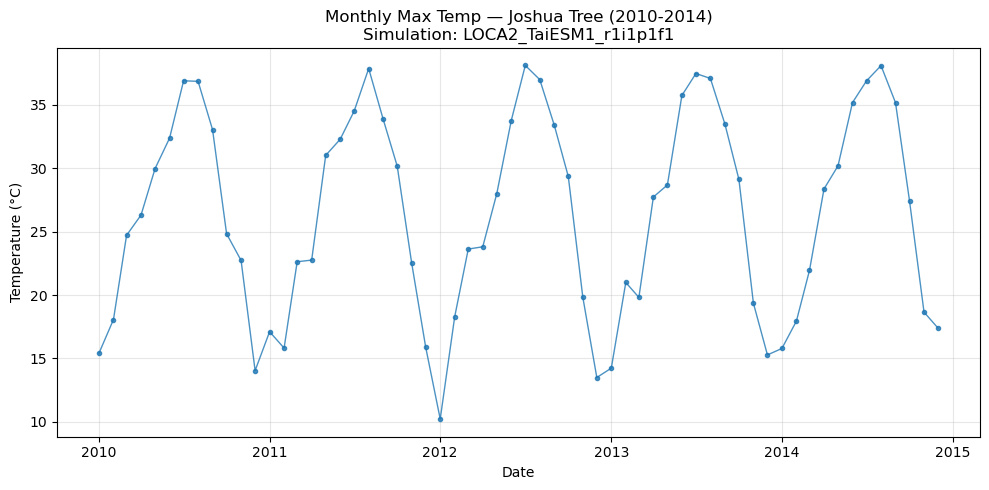


 Plotted 60 monthly values.
  Total simulations available: 70


In [5]:
# Use Strategy A's T_Max result for plotting (our gold-standard pipeline)
spatial_avg = results_a["T_Max"]

# Convert to dataframe for easy plotting
df = spatial_avg.to_dataframe(name='TMax').reset_index()
df['Year'] = df['time'].dt.year
df['Month'] = df['time'].dt.month

# If there's a simulation dimension, pick the first one for a quick plot
sim_col = None
if 'simulation' in df.columns:
    sim_col = 'simulation'
elif 'source_id' in df.columns:
    sim_col = 'source_id'

fig, ax = plt.subplots(figsize=(10, 5))

if sim_col:
    first_sim = df[sim_col].unique()[0]
    plot_df = df[df[sim_col] == first_sim]
    ax.set_title(f"Monthly Max Temp — Joshua Tree (2010-2014)\nSimulation: {first_sim}")
else:
    plot_df = df
    ax.set_title("Monthly Max Temp — Joshua Tree (2010-2014)")

ax.plot(plot_df['time'], plot_df['TMax'], marker='.', linewidth=1, alpha=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Plotted {len(plot_df)} monthly values.")
if sim_col:
    print(f"  Total simulations available: {df[sim_col].nunique()}")

## 7. CSV Export Test

In [6]:
output_file = os.path.join(OUTPUT_DIR, "test_output.csv")

export_df = df[['time', 'TMax']].copy() if sim_col is None else df[['time', sim_col, 'TMax']].copy()
export_df['Year'] = df['Year']
export_df['Month'] = df['Month']
export_df['Region'] = 'JoshuaTree'
export_df['Variable'] = 'T_Max'
export_df['Scenario'] = 'Historical Climate'

export_df.to_csv(output_file, index=False)

# Verify
check = pd.read_csv(output_file)
print(f" CSV saved: {output_file}")
print(f"  Rows: {len(check)}")
print(f"  Columns: {list(check.columns)}")
print(f"\nFirst 5 rows:")
check.head()

 CSV saved: /Users/andrewschoenen/Desktop/DSE/data/csv/test_output.csv
  Rows: 4200
  Columns: ['time', 'simulation', 'TMax', 'Year', 'Month', 'Region', 'Variable', 'Scenario']

First 5 rows:


,time,simulation,TMax,Year,Month,Region,Variable,Scenario
0,2010-01-01,LOCA2_TaiESM1_r1i1p1f1,15.410267,2010,1,JoshuaTree,T_Max,Historical Climate
1,2010-02-01,LOCA2_TaiESM1_r1i1p1f1,18.067032,2010,2,JoshuaTree,T_Max,Historical Climate
2,2010-03-01,LOCA2_TaiESM1_r1i1p1f1,24.712315,2010,3,JoshuaTree,T_Max,Historical Climate
3,2010-04-01,LOCA2_TaiESM1_r1i1p1f1,26.319042,2010,4,JoshuaTree,T_Max,Historical Climate
4,2010-05-01,LOCA2_TaiESM1_r1i1p1f1,29.980194,2010,5,JoshuaTree,T_Max,Historical Climate


## Summary

If all cells above ran without errors, your setup is good:

| Check | Status |
|-------|--------|
| climakitae imports | ✓ |
| Cal-Adapt data fetch | ✓ |
| Shapefile loading | ✓ |
| Spatial masking (rioxarray) | ✓ |
| Weighted spatial average | ✓ |
| Dask → memory (.load()) | ✓ |
| Matplotlib plotting | ✓ |
| CSV export + read-back | ✓ |

You're ready to run the full `01_fetch_climate_data.ipynb` notebook!